In [31]:
#To install required packages
import warnings
warnings.filterwarnings("ignore")

In [3]:
#To import required packages
import pandas as pd
import sqlite3
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import ttest_ind
import scipy.stats as stats

In [4]:
conn = sqlite3.connect('vendor_performance.db')
vendor_sales_summary = pd.read_sql("""select * from vendor_sales_summary;""", conn)
vendor_sales_summary.head()

,VendorNumber,VendorName,Description,Brand,Volume,purchase_price,total_quantity,total_dollars,Actual_Price,total_sales,total_sales_quantity,sales_price,total_excise_tax,avg_freight_cost,gross_profit_per_unit,profit_margin,stock_turnover_ratio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",Ch Lilian 09 Ladouys St Este,90085,750.0,23.86,8,190.88,23.86,665.82,18,36.990000,2.00,0.110898,12.769102,0.345204,2.250000
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",Flavor Essence Variety 5 Pak,90609,162.5,17.00,320,5440.00,17.00,599.76,24,24.990000,0.52,0.110898,7.877477,0.315225,0.075000
2,60,ADAMBA IMPORTS INTL INC,Bak's Krupnik Honey Liqueur,771,750.0,11.44,39,446.16,11.44,704.53,47,14.990000,37.01,0.078518,2.522507,0.168279,1.205128
3,60,ADAMBA IMPORTS INTL INC,Vesica Potato Vodka,3979,1750.0,16.27,4687,76257.49,16.27,66871.69,3931,17.020216,7224.06,0.078518,-0.869599,-0.051092,0.838703
4,105,ALTAMAR BRANDS LLC,Right Gin,2529,750.0,23.25,12,279.00,23.25,359.88,12,29.990000,9.44,0.192555,5.760778,0.192090,1.000000


In [5]:
vendor_sales_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10470.0,10589.840783,18606.754468,2.000000,3924.000000,7153.000000,9552.000000,1.733570e+05
Brand,10470.0,17990.606399,12670.262908,58.000000,5740.250000,18668.500000,25480.750000,9.063100e+04
Volume,10470.0,848.270535,669.031537,50.000000,750.000000,750.000000,750.000000,2.000000e+04
purchase_price,10470.0,23.422344,92.349748,0.360000,6.840000,10.400000,19.370000,4.264700e+03
total_quantity,10470.0,3197.416141,11200.125944,1.000000,36.000000,279.000000,2034.500000,3.376600e+05
total_dollars,10470.0,30623.588984,124263.050478,0.710000,477.575000,3812.990000,21306.765000,3.811252e+06
Actual_Price,10470.0,23.422344,92.349748,0.360000,6.840000,10.400000,19.370000,4.264700e+03
total_sales,10470.0,43022.111714,169277.639844,1.980000,809.730000,5580.080000,29568.777500,5.101920e+06
total_sales_quantity,10470.0,3134.297326,11056.523787,1.000000,36.000000,279.000000,1989.250000,3.349390e+05
sales_price,10470.0,33.856979,126.577137,0.490000,10.490000,15.491036,27.990000,5.799990e+03


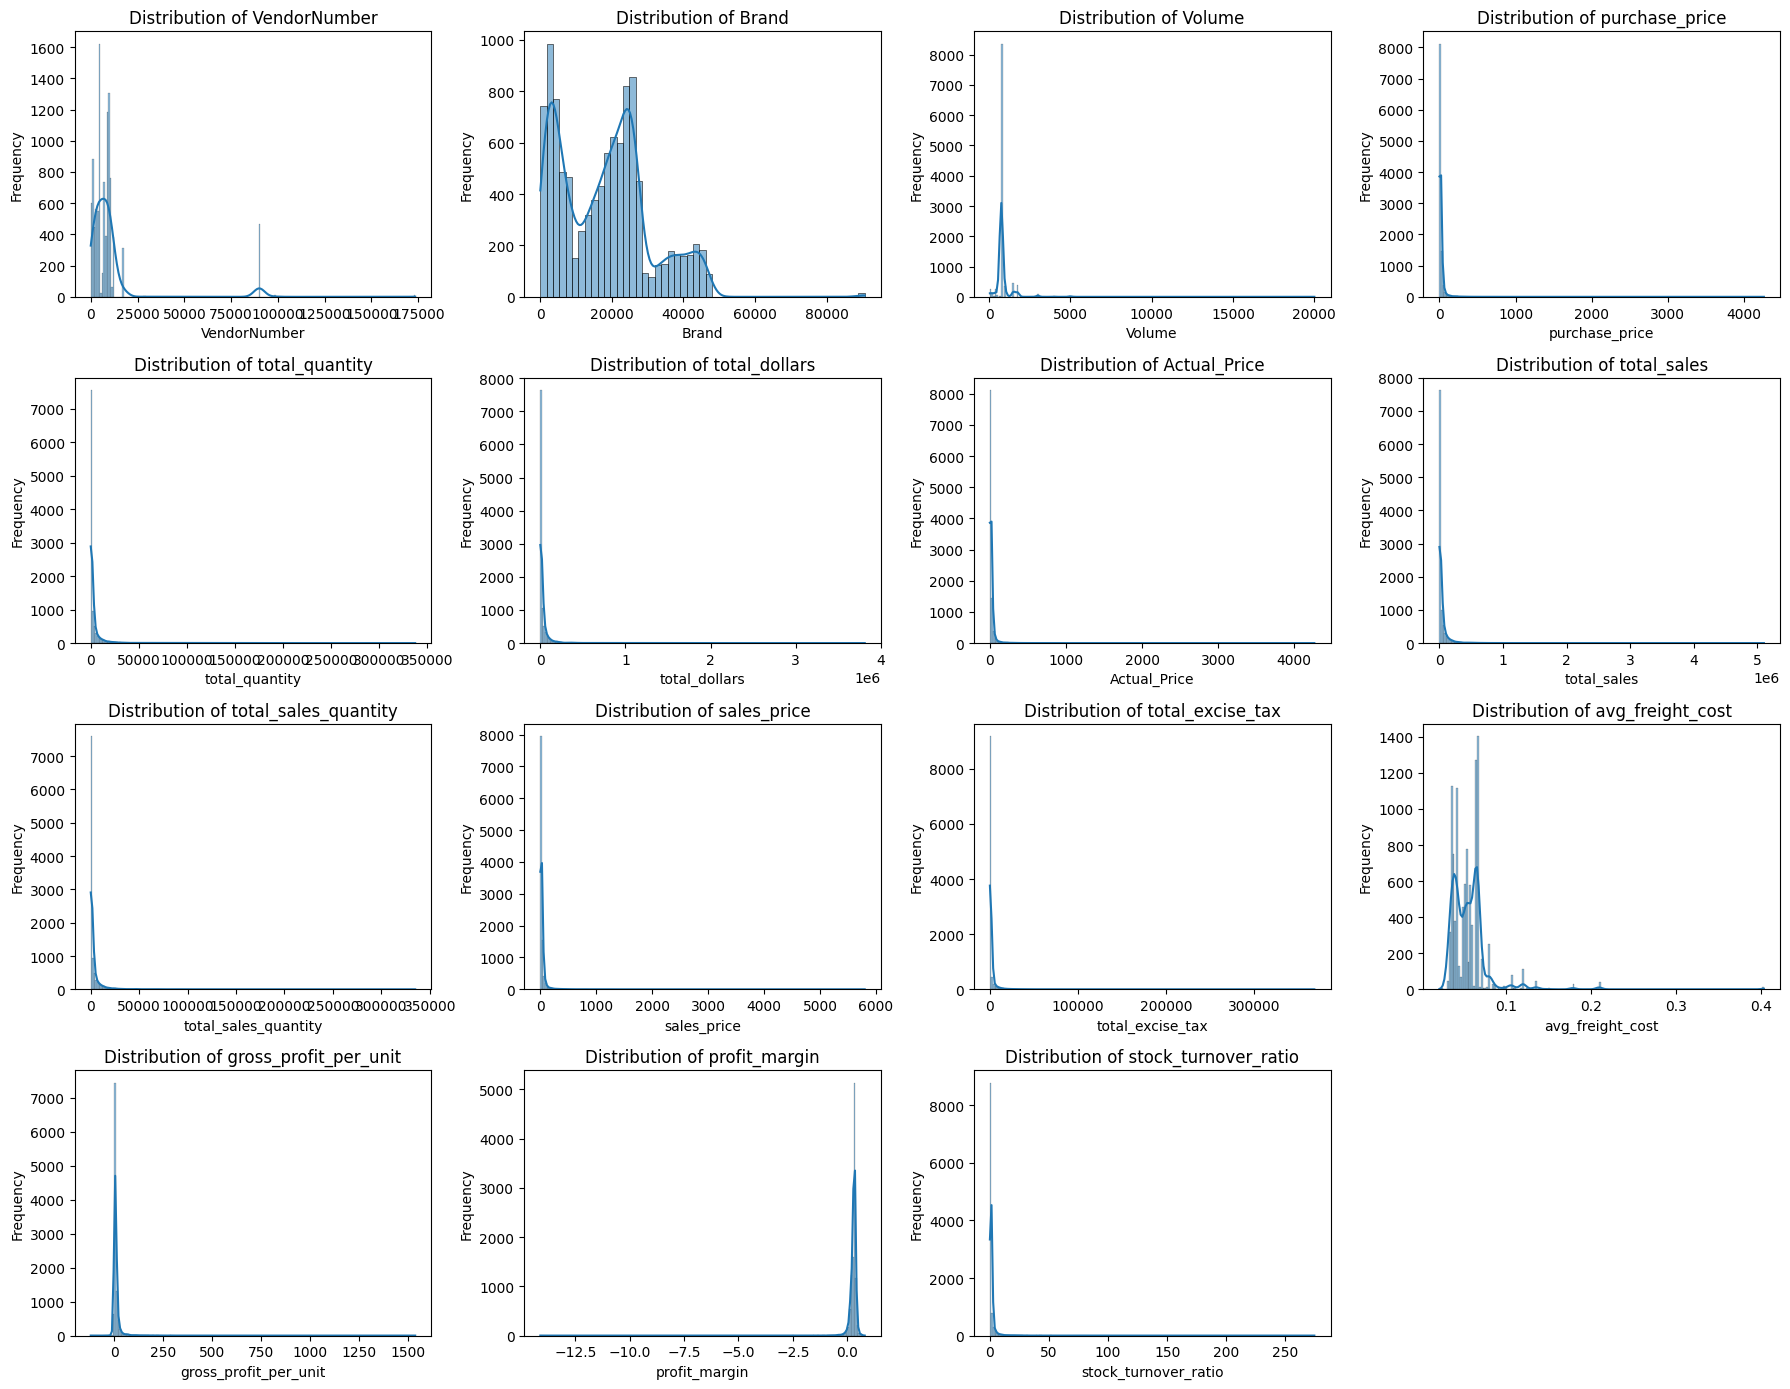

In [18]:
num_cols = vendor_sales_summary.select_dtypes(include=np.number).columns


plt.figure(figsize=(18, 14))

for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)      # create subplot
    sns.histplot(vendor_sales_summary[col], kde=True)
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()


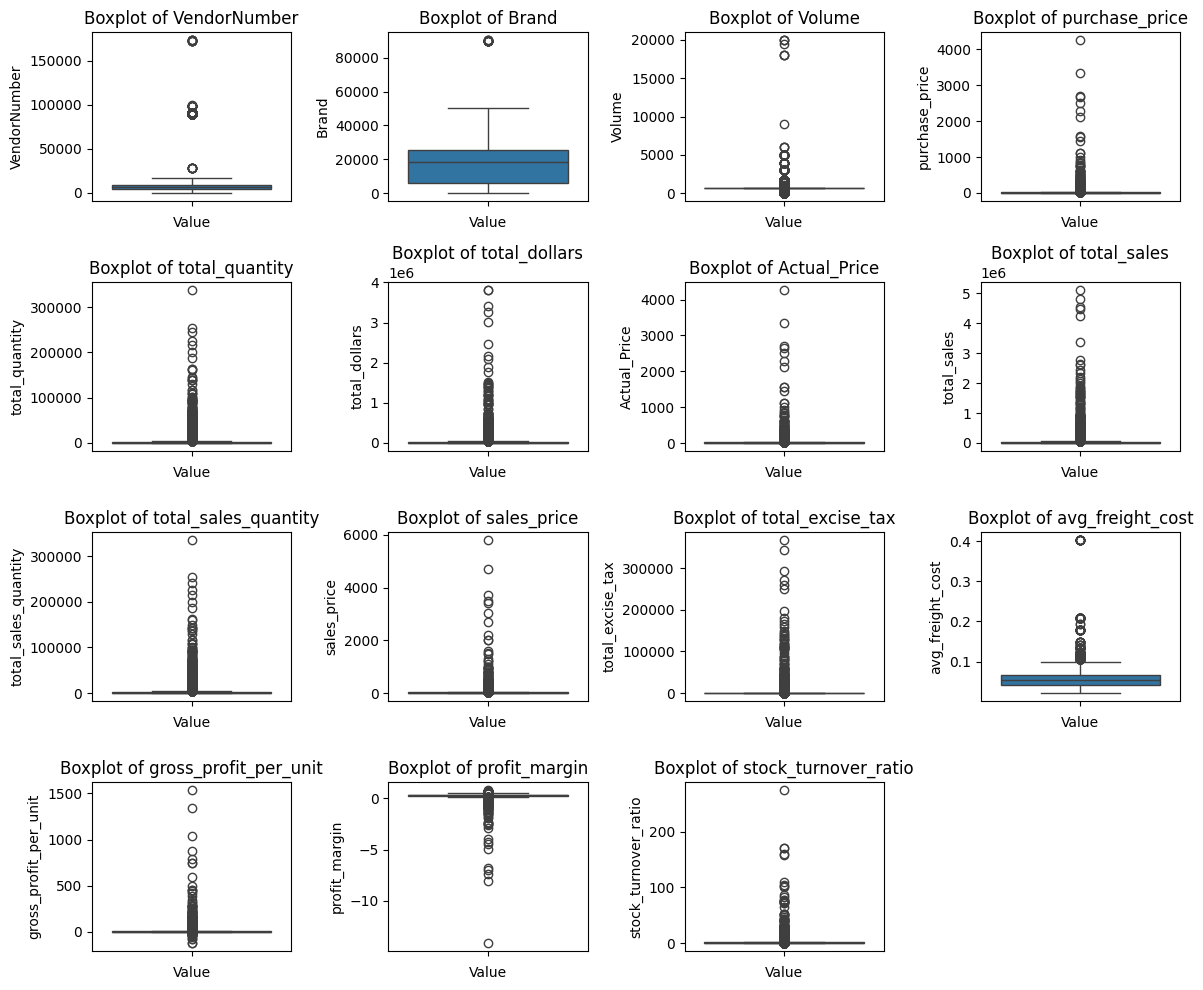

In [21]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=vendor_sales_summary[col])
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)
    plt.xlabel('Value', fontsize=10)

plt.tight_layout()
plt.show()

In [22]:
vendor_sales_summary_not_zero = pd.read_sql("""select * from vendor_sales_summary
                                where profit_margin > 0;""", conn)
vendor_sales_summary_not_zero.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10173.0,10660.695173,18783.683909,2.000000,3924.000000,7153.000000,9552.000000,1.733570e+05
Brand,10173.0,18241.376978,12654.793322,58.000000,6193.000000,18909.000000,25561.000000,9.063100e+04
Volume,10173.0,849.604885,674.770566,50.000000,750.000000,750.000000,750.000000,2.000000e+04
purchase_price,10173.0,23.762457,93.652734,0.360000,6.840000,10.450000,19.590000,4.264700e+03
total_quantity,10173.0,3264.090141,11348.138131,1.000000,36.000000,296.000000,2077.000000,3.376600e+05
total_dollars,10173.0,31260.426187,125964.648771,1.480000,505.240000,4037.980000,21711.900000,3.811252e+06
Actual_Price,10173.0,23.762457,93.652734,0.360000,6.840000,10.450000,19.590000,4.264700e+03
total_sales,10173.0,43997.381241,171606.460296,1.980000,809.460000,5711.030000,30399.610000,5.101920e+06
total_sales_quantity,10173.0,3193.484125,11204.235136,1.000000,36.000000,278.000000,2026.000000,3.349390e+05
sales_price,10173.0,34.460532,128.349468,0.490000,10.618792,15.838807,28.332105,5.799990e+03


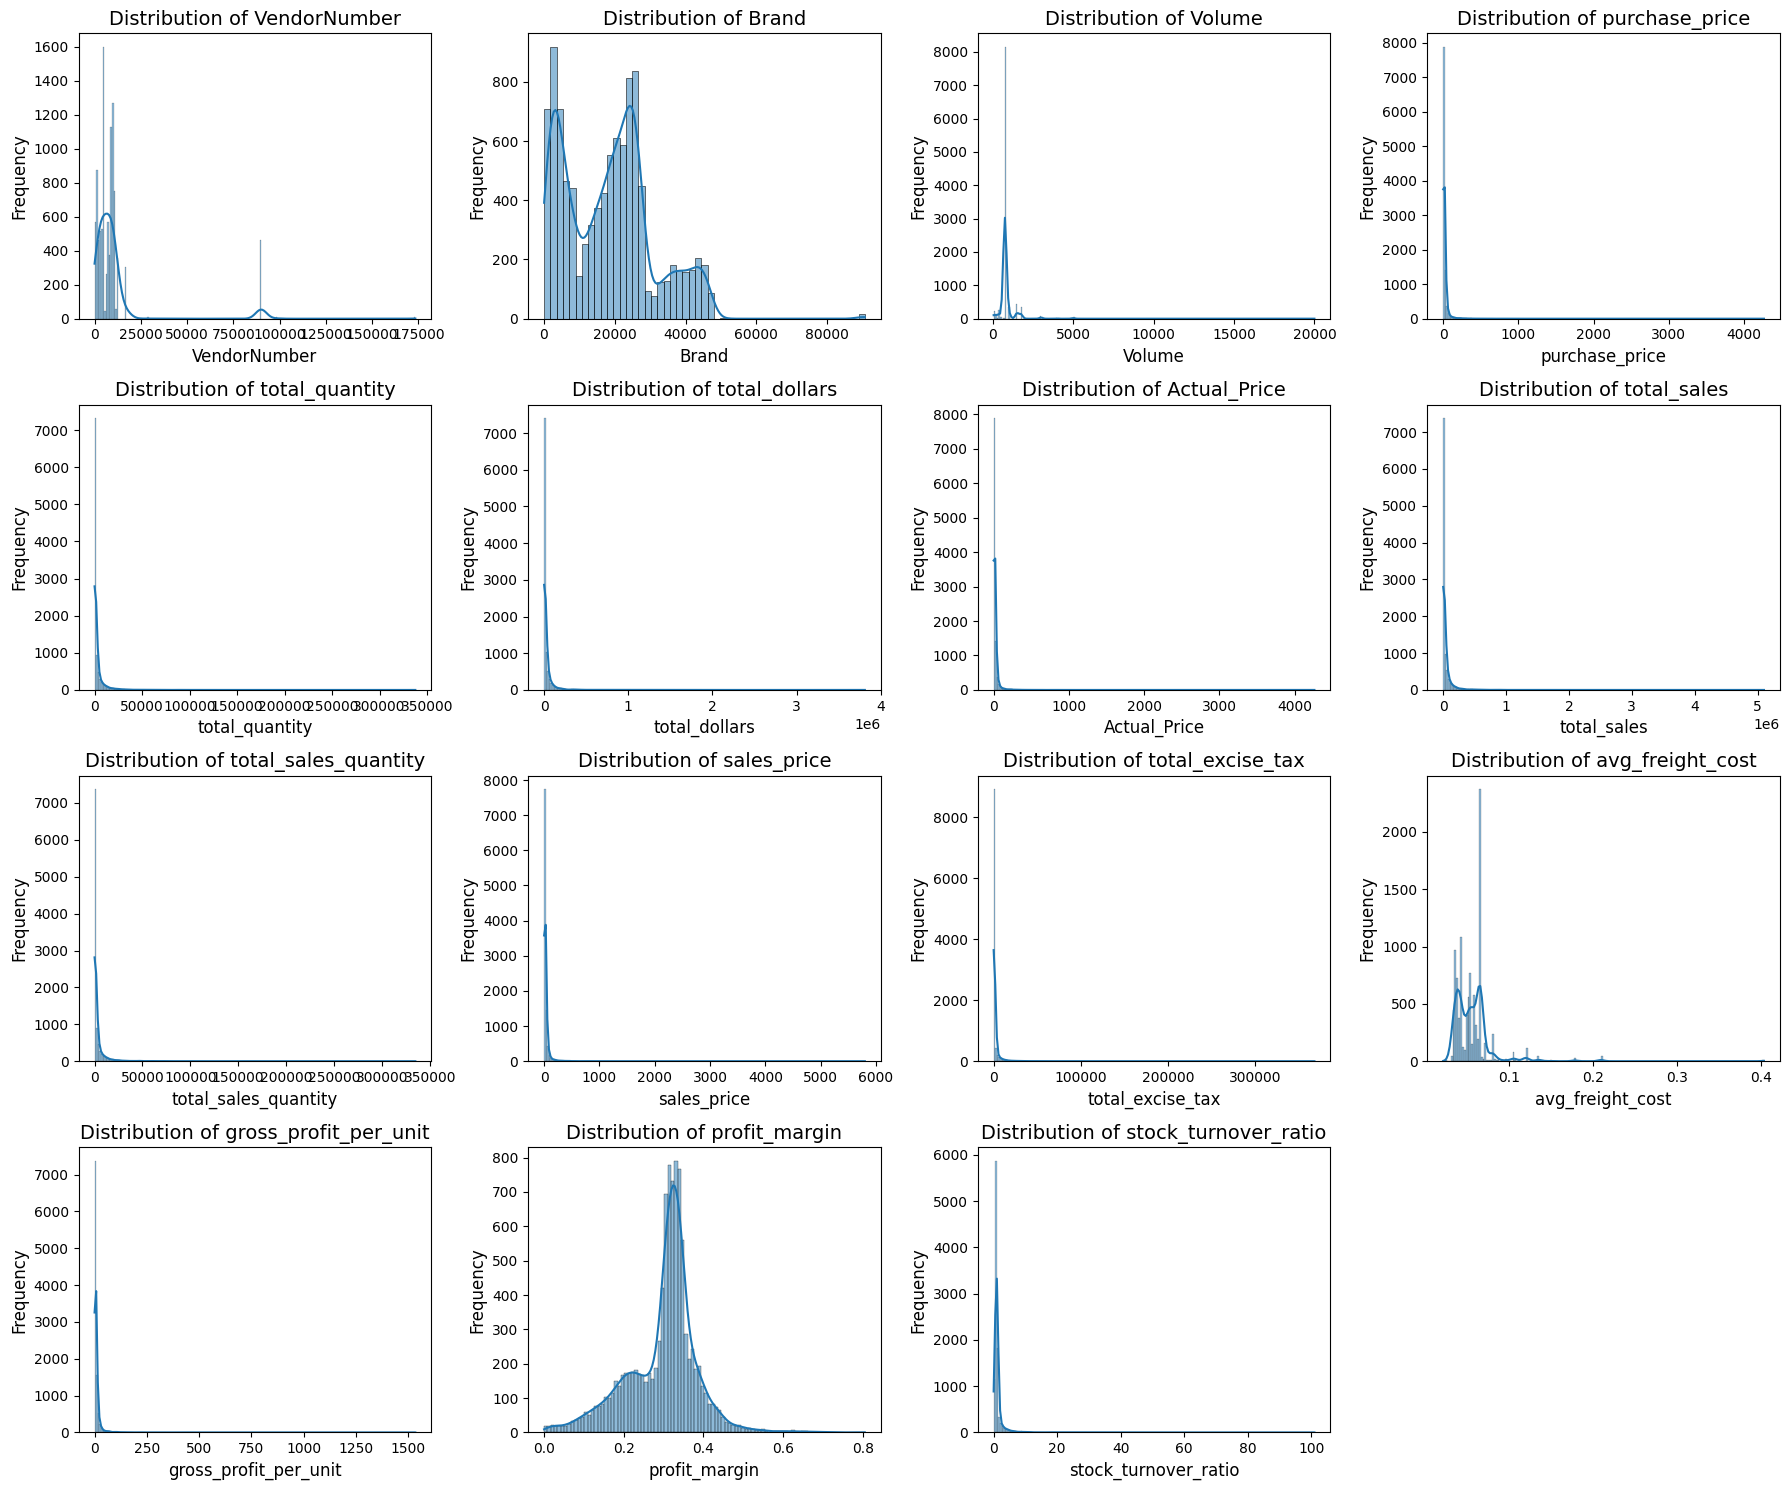

In [ ]:
#distribution plots for non-zero profit margin data
plt.figure(figsize=(18, 15))

for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)      # create subplot
    sns.histplot(vendor_sales_summary_not_zero[col], kde=True)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()    
plt.show()

Text(0.5, 1.0, 'Correlation Matrix of Numerical Features')

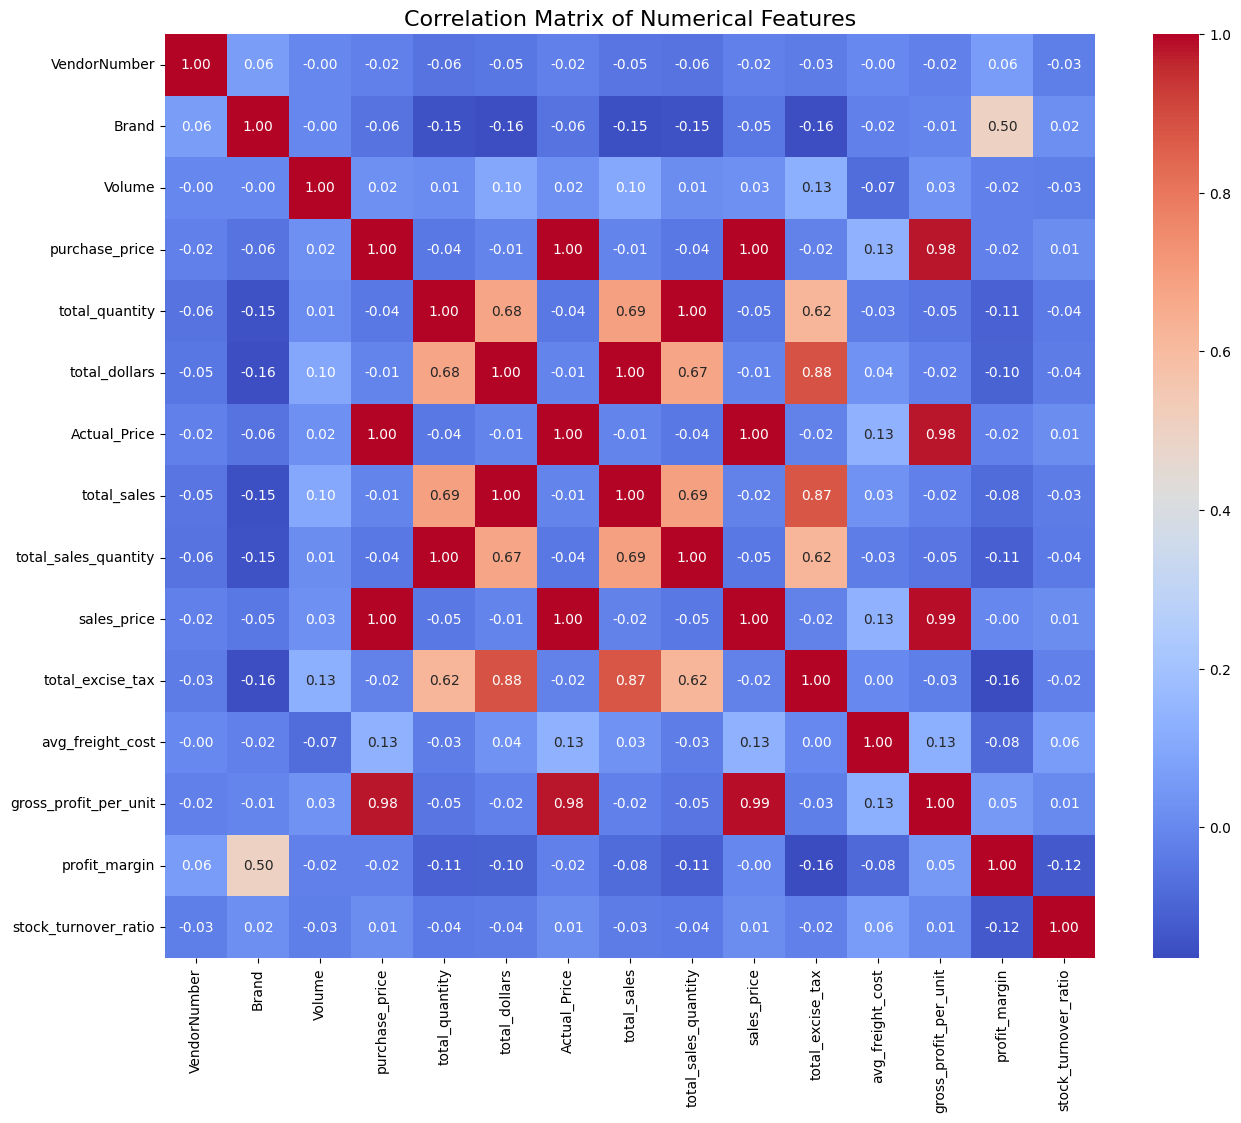

In [28]:
plt.figure(figsize=(15,12))
corelation_matrix = vendor_sales_summary_not_zero[num_cols].corr()
sns.heatmap(corelation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features', fontsize=16)

# Data Analysis

Idenitfy Brand that need promotional support or price adjustment which exhibit low sales volume but high profit margin.

In [72]:
brand_performance = vendor_sales_summary_not_zero.groupby('Description').agg({
    'total_sales': 'sum',
    'profit_margin': 'mean'})
threshold_sales = brand_performance['total_sales'].quantile(0.15)
threshold_profit = brand_performance['profit_margin'].quantile(0.85)
target_brand = brand_performance[ (brand_performance['total_sales'] <= threshold_sales) &
                                                (brand_performance['profit_margin'] >= threshold_profit)
                                               ]
target_brand = target_brand.sort_values(by='profit_margin', ascending=False)
target_brand


,total_sales,profit_margin
Description,,
Viberti Chard,308.23,0.805336
Circadia Cab Svgn Napa Vly,74.99,0.678166
Ch Pagodes de Cos 10 Brdx,99.99,0.673694
Los Dos Moscato & Chard,159.85,0.657978
Santa Rita Organic Svgn Bl,9.99,0.649526
...,...,...
Riebeek Cellars Pinotage,32.97,0.370173
Parducci Small Lot Pnt Gris,85.93,0.369935
Moobuzz Pnt Nr,114.93,0.368911


In [76]:
brand_performance = brand_performance[brand_performance['total_sales'] < 10000]

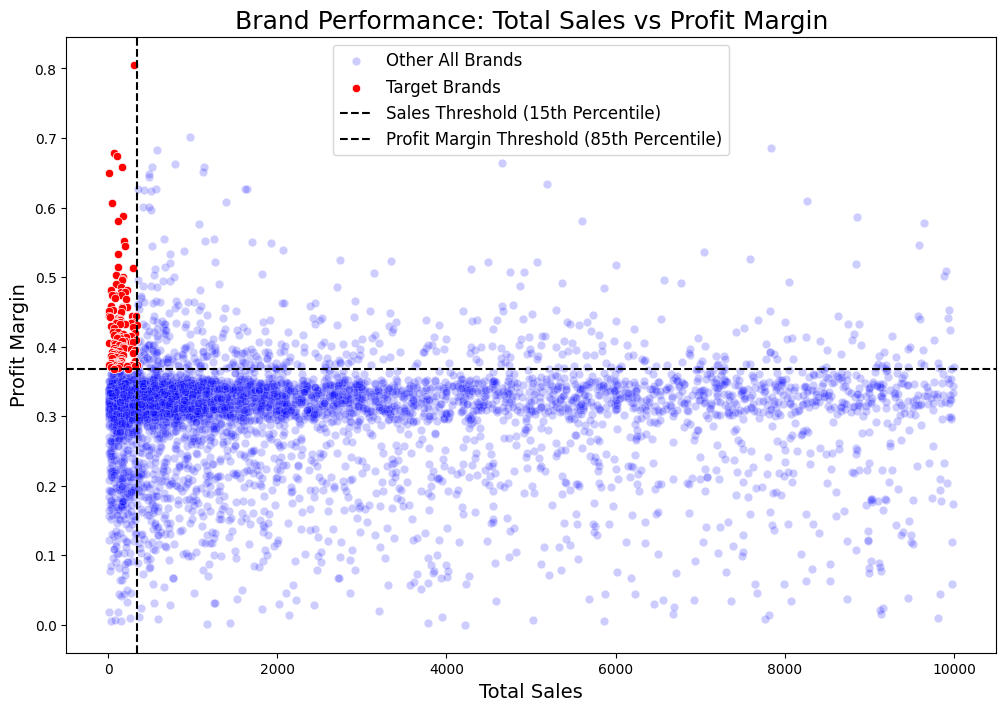

In [78]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=brand_performance, x='total_sales', y='profit_margin',color='blue', label='Other All Brands', alpha=0.2)
sns.scatterplot(data=target_brand, x='total_sales', y='profit_margin', color='red', label='Target Brands')
plt.axvline(x=threshold_sales, color='black', linestyle='--', label='Sales Threshold (15th Percentile)')
plt.axhline(y=threshold_profit, color='black', linestyle='--', label='Profit Margin Threshold (85th Percentile)')
plt.title('Brand Performance: Total Sales vs Profit Margin', fontsize=18)
plt.xlabel('Total Sales', fontsize=14)  
plt.ylabel('Profit Margin', fontsize=14)
plt.legend(fontsize=12)
plt.show()


Identify top brands and vendor based on total sales

In [81]:
def format_dollar(value):
    if value >= 1_000_000:
        return f"${value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"${value/1_000:.2f}K"

In [82]:
top_vendor_name = vendor_sales_summary_not_zero.groupby('VendorName')['total_sales'].sum().reset_index().nlargest(10, 'total_sales')
top_brand_desc = vendor_sales_summary_not_zero.groupby('Description')['total_sales'].sum().reset_index().nlargest(10, 'total_sales')
top_vendor_name['total_sales'] = top_vendor_name['total_sales'].apply(format_dollar)
top_brand_desc['total_sales'] = top_brand_desc['total_sales'].apply(format_dollar)
display(top_vendor_name)
display(top_brand_desc)

,VendorName,total_sales
26,DIAGEO NORTH AMERICA INC,$68.58M
59,MARTIGNETTI COMPANIES,$40.65M
70,PERNOD RICARD USA,$32.22M
47,JIM BEAM BRANDS COMPANY,$31.79M
7,BACARDI USA INC,$24.78M
21,CONSTELLATION BRANDS INC,$24.40M
31,E & J GALLO WINERY,$18.50M
13,BROWN-FORMAN CORP,$18.40M
110,ULTRA BEVERAGE COMPANY LLP,$17.34M
55,M S WALKER INC,$15.09M


,Description,total_sales
4494,Jack Daniels No 7 Black,$7.96M
8516,Tito's Handmade Vodka,$7.40M
4030,Grey Goose Vodka,$7.21M
1494,Capt Morgan Spiced Rum,$6.36M
105,Absolut 80 Proof,$6.24M
4604,Jameson Irish Whiskey,$5.72M
4894,Ketel One Vodka,$5.07M
560,Baileys Irish Cream,$4.15M
4805,Kahlua,$3.60M
8197,Tanqueray,$3.46M


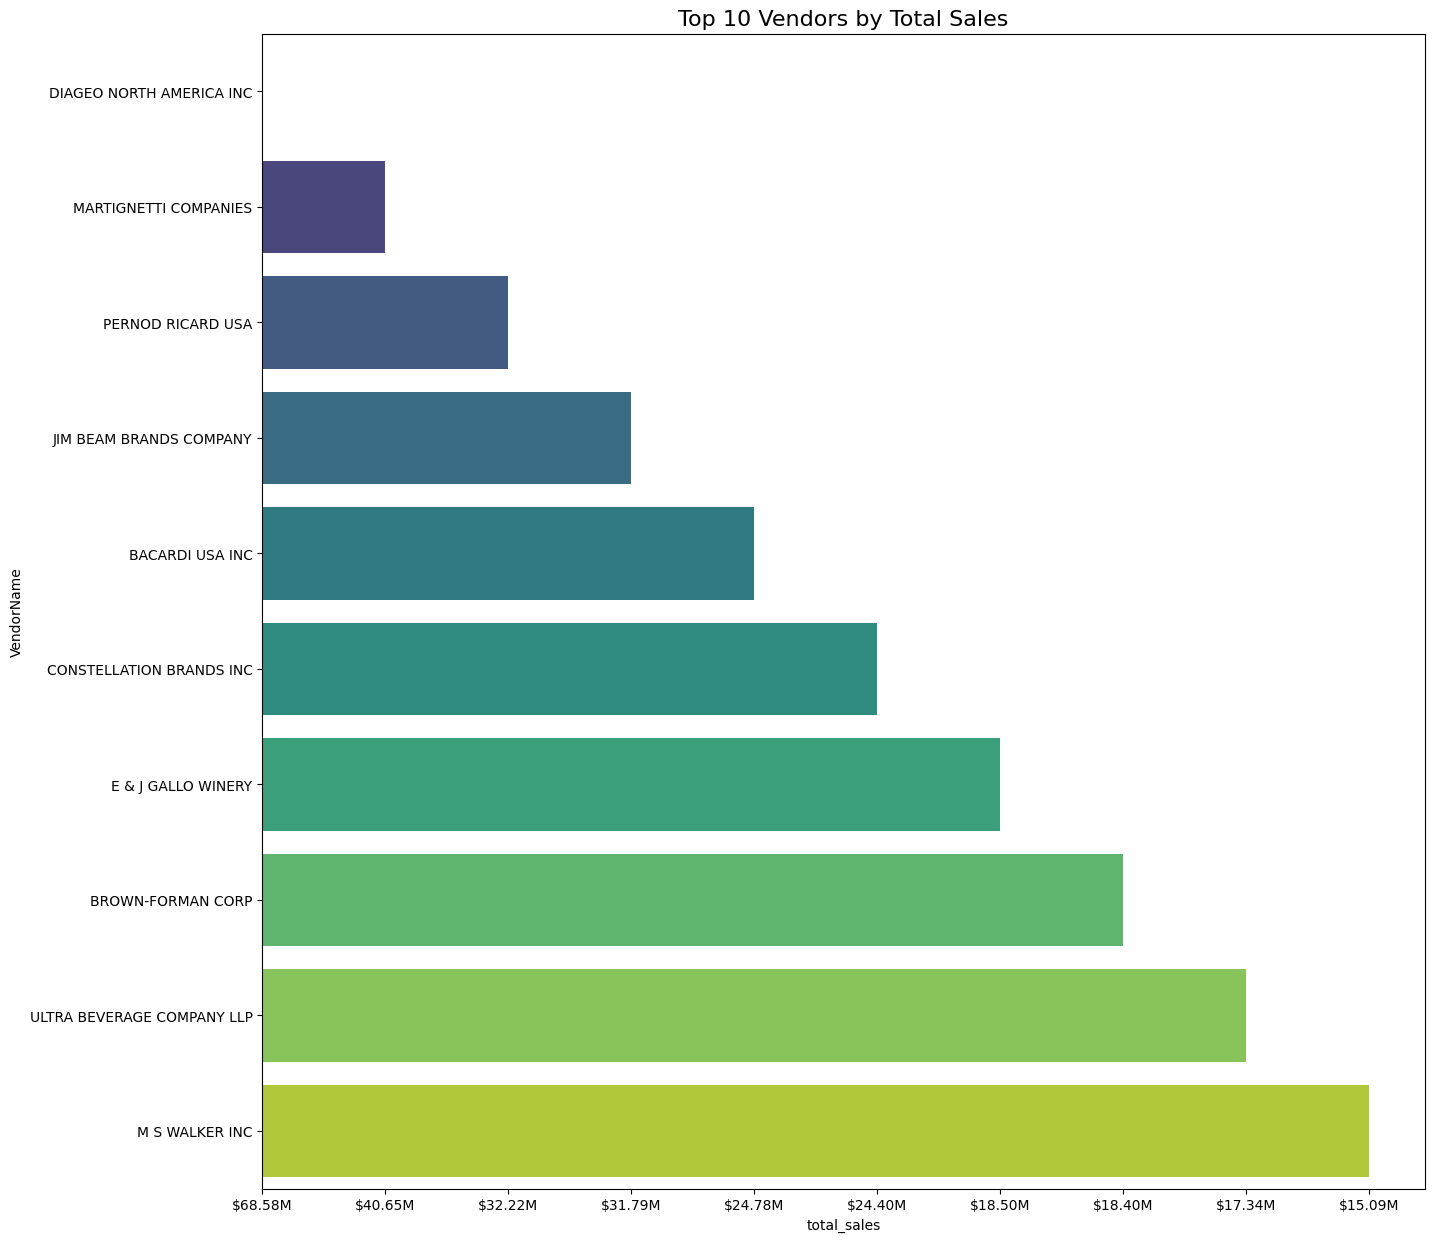

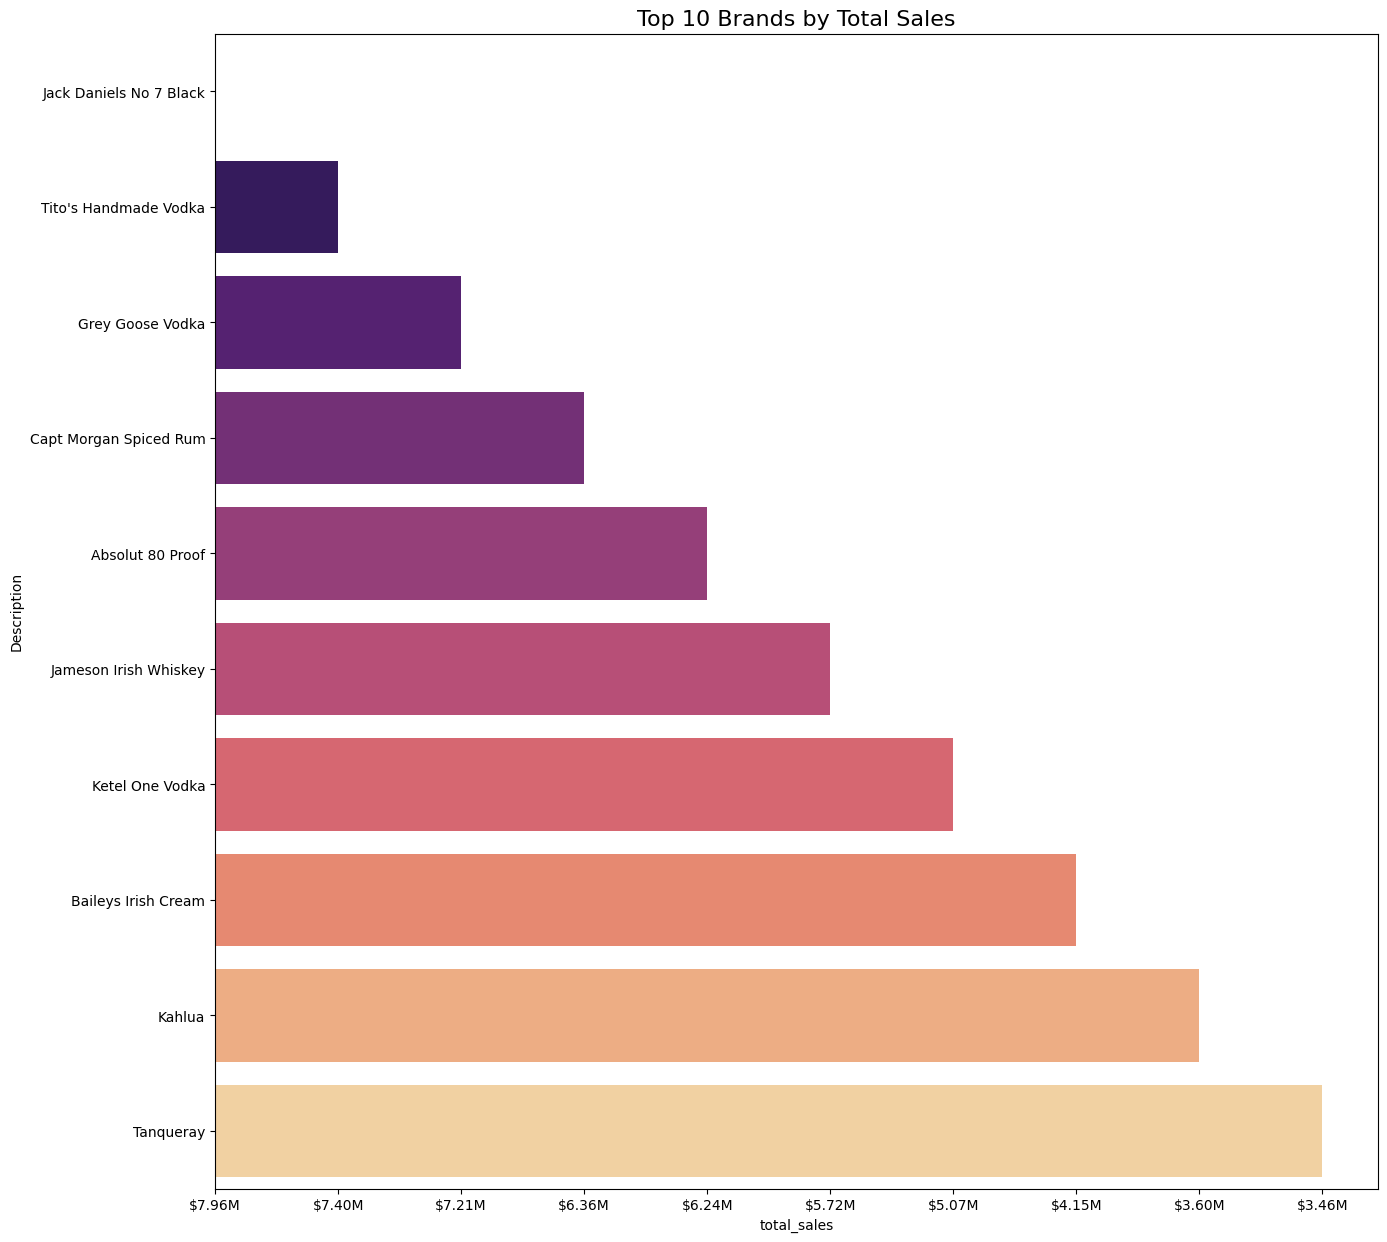

In [106]:
plt.figure(figsize=(15, 15))
sns.barplot(
    x=top_vendor_name['total_sales'], 
    y=top_vendor_name['VendorName'],
    palette='viridis',
    orient= 'h'
)
plt.title('Top 10 Vendors by Total Sales', fontsize=16)

plt.figure(figsize=(15, 15))
sns.barplot(
    data=top_brand_desc,
    x='total_sales',
    y='Description',
    palette='magma',
    orient= 'h'
)
plt.title('Top 10 Brands by Total Sales', fontsize=16)
plt.show()
